# F1 Strategy Predictor
## Real-Time Race Simulator

---

Simulates F1 races using trained LSTM models to predict:
1. **Pit Stop Timing**: Probability of pit for each lap
2. **Tire Compound**: SOFT, MEDIUM, HARD, INTERMEDIATE

### Requirements
- `f1_pit_model.keras`, `f1_compound_model.keras`,  `f1_pit_scaler.pkl`, `f1_comp_scaler.pkl`, `label_encoder.pkl`, `modelConfig.json`, `f1_dataset_featured.pkl`

# 1. Setup

In [1]:
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.5 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np

import pandas as pd

from io import BytesIO
import requests
import os
import tempfile

import matplotlib.pyplot as plt

import json

import joblib

from tensorflow.keras.models import load_model

In [3]:
# Compound colors and labels
COMPOUND_COLORS = {
    'SOFT': '#FF3333',
    'MEDIUM': '#FFD700',
    'HARD': '#E8E8E8',
    'INTERMEDIATE': '#39FF14'
}
COMPOUND_SHORT = {'SOFT': 'S', 'MEDIUM': 'M', 'HARD': 'H', 'INTERMEDIATE': 'I'}

In [ ]:
BASE_URL = (
    "https://raw.githubusercontent.com/"
    "FedericoSabbadini/f1-strategy-predictor/"
    "main/03:model/output/Model/"
)

def download_bytes(url: str) -> bytes:
    r = requests.get(url)
    r.raise_for_status()
    return r.content

def load_keras_from_url(url: str):
    with tempfile.NamedTemporaryFile(suffix=".keras", delete=False) as f:
        f.write(download_bytes(url))
        path = f.name
    model = load_model(path)
    os.remove(path)
    return model

In [ ]:
model_pit = load_keras_from_url(BASE_URL + "f1_pit_model.keras")
model_comp = load_keras_from_url(BASE_URL + "f1_compound_model.keras")

scaler_pit = joblib.load(BytesIO(download_bytes(BASE_URL + "f1_pit_scaler.pkl")))
scaler_comp = joblib.load(BytesIO(download_bytes(BASE_URL + "f1_comp_scaler.pkl")))

label_encoder = joblib.load(BytesIO(download_bytes(BASE_URL + "label_encoder.pkl")))

df_f1 = pd.read_pickle(BASE_URL+"f1_dataset_featured.pkl")

config = json.loads(download_bytes(BASE_URL + "modelConfig.json"))

In [ ]:
# Config
SEQ_LEN = config['sequence_length']
FEATURES_PIT = config['FEATURES']
FEATURES_COMP = FEATURES_PIT
PIT_THRESHOLD = config['pit_threshold']
WINDOW = 3  # Final laps window

---
# 2. Race Selection

Run cells below to see available options.

### 2.1 Available Years

In [4]:
years = sorted(df_f1['Year'].unique())
print('Available years:')
print(', '.join(map(str, years)))

Available years:
2022, 2023, 2024, 2025


*Select year:* [ex. YEAR = 2023]

In [5]:
YEAR = 2023

### 2.2 Available Races

In [6]:
races = df_f1[df_f1['Year'] == YEAR][['Round', 'RaceName']].drop_duplicates().sort_values('Round')
print(f'Races {YEAR}:')
print('-' * 40)
for _, row in races.iterrows():
    print(f"  {int(row['Round']):>2}. {row['RaceName']}")

Races 2023:
----------------------------------------
   1. Bahrain Grand Prix
   2. Saudi Arabian Grand Prix
   3. Australian Grand Prix
   4. Azerbaijan Grand Prix
   5. Miami Grand Prix
   6. Monaco Grand Prix
   7. Spanish Grand Prix
   8. Canadian Grand Prix
   9. Austrian Grand Prix
  10. British Grand Prix
  11. Hungarian Grand Prix
  12. Belgian Grand Prix
  13. Dutch Grand Prix
  14. Italian Grand Prix
  15. Singapore Grand Prix
  16. Japanese Grand Prix
  17. Qatar Grand Prix
  18. United States Grand Prix
  19. Mexico City Grand Prix
  20. São Paulo Grand Prix
  21. Las Vegas Grand Prix
  22. Abu Dhabi Grand Prix


*Select race:* [ex. ROUND = 21]

In [7]:
ROUND = 22

### 2.3 Available Drivers

In [8]:
race_df = df_f1[(df_f1['Year'] == YEAR) & (df_f1['Round'] == ROUND)]
race_name = race_df['RaceName'].iloc[0] if len(race_df) > 0 else 'N/A'

drivers = race_df[['Driver', 'Team']].drop_duplicates().sort_values('Team')
print(f'{race_name} {YEAR}')
print('-' * 40)
print(f'{"Driver":<8} {"Team":<25}')
print('-' * 40)
for _, row in drivers.iterrows():
    print(f"{row['Driver']:<8} {row['Team']:<25}")

Abu Dhabi Grand Prix 2023
----------------------------------------
Driver   Team                     
----------------------------------------
OCO      Alpine                   
GAS      Alpine                   
ALO      Aston Martin             
STR      Aston Martin             
SAI      Ferrari                  
LEC      Ferrari                  
HUL      Haas F1 Team             
MAG      Haas F1 Team             
ZHO      Kick Sauber              
BOT      Kick Sauber              
PIA      McLaren                  
NOR      McLaren                  
RUS      Mercedes                 
HAM      Mercedes                 
RIC      Racing Bulls             
TSU      Racing Bulls             
VER      Red Bull Racing          
PER      Red Bull Racing          
SAR      Williams                 
ALB      Williams                 


*Select driver:* [ex. DRIVER = 'LAW']

In [9]:
DRIVER = 'VER'

### 2.4 Real Race Summary

In [10]:
race_data = df_f1[(df_f1['Year'] == YEAR) & (df_f1['Round'] == ROUND)].copy()
race_name = race_data['RaceName'].iloc[0] if len(race_data) > 0 else None

if race_name and DRIVER in race_data['Driver'].values:
    driver_data = race_data[race_data['Driver'] == DRIVER].sort_values('LapNumber')
    total_laps = int(driver_data['LapNumber'].max())
    team = driver_data['Team'].iloc[0]

    # Build strategy string
    stints_info = []
    for stint in sorted(driver_data['Stint'].unique()):
        stint_df = driver_data[driver_data['Stint'] == stint]
        compound = stint_df['Compound'].iloc[0]
        n_laps = int(stint_df['LapNumber'].max() - stint_df['LapNumber'].min()) + 1
        stints_info.append(f"{COMPOUND_SHORT.get(compound, '?')}({n_laps})")

    # Safety car laps
    sc_laps = []
    if 'UnderCaution' in driver_data.columns:
        sc_laps = driver_data[driver_data['UnderCaution'] == 1]['LapNumber'].astype(int).tolist()

    print('=' * 50)
    print(f'  {race_name} {YEAR}')
    print(f'  {DRIVER} - {team}')
    print('=' * 50)
    print(f'  Total laps: {total_laps}')
    print(f'  Stints: {driver_data["Stint"].nunique()}')
    print(f'  Strategy: {" > ".join(stints_info)}')
    if sc_laps:
        print(f'  Safety Car: {len(sc_laps)} laps')
    print('=' * 50)
else:
    print('ERROR: Race or driver not found')
    print(f'  Year: {YEAR}, Round: {ROUND}, Driver: {DRIVER}')

  Abu Dhabi Grand Prix 2023
  VER - Red Bull Racing
  Total laps: 58
  Stints: 3
  Strategy: M(14) > H(25) > H(14)


---
# 3. Simulation

Processes each lap, builds sequences, and generates predictions.

In [11]:
class RaceSimulator:
    """
    Simulates a race lap-by-lap, producing:
    - real-time pit stop probability predictions
    - compound predictions at pit stops
    - recommended pit laps per stint
    """

    def __init__(self, model_pit, model_comp, scaler_pit, scaler_comp,
                 label_encoder, features_pit, features_comp,
                 seq_len, threshold, window=3):
        """
        Store all models, preprocessors, and configuration.
        Nothing is learned here; this is pure setup.
        """
        self.model_pit = model_pit            # Binary classifier: pit vs no-pit
        self.model_comp = model_comp          # Multiclass classifier: tyre compound

        self.scaler_pit = scaler_pit          # Feature scaler for PIT model
        self.scaler_comp = scaler_comp        # Feature scaler for COMPOUND model

        self.label_encoder = label_encoder    # Decodes compound class indices → labels

        # Keep only features that actually exist in the dataframe
        self.features_pit = [f for f in features_pit if f in df_f1.columns]
        self.features_comp = [f for f in features_comp if f in df_f1.columns]

        self.seq_len = seq_len                # LSTM sequence length
        self.threshold = threshold            # Decision threshold for PIT prediction
        self.window = window                  # Final laps window where pits are discouraged

    def _prepare_sequence(self, history_df, features, scaler):
        """
        Convert historical lap data into a fixed-length LSTM input.
        Output shape: (1, seq_len, n_features)
        """

        # Case 1: no history yet → return fully padded sequence
        if len(history_df) == 0:
            return np.zeros((1, self.seq_len, len(features)), dtype=np.float32)

        # Scale numeric features (same scaler used during training)
        data = scaler.transform(
            history_df[features].values.astype(np.float32)
        )

        # If sequence is shorter than seq_len → LEFT PAD with zeros
        if len(data) < self.seq_len:
            pad = np.zeros((self.seq_len - len(data), len(features)), dtype=np.float32)
            data = np.vstack([pad, data])
        else:
            # Otherwise keep only the most recent seq_len laps
            data = data[-self.seq_len:]

        # Add batch dimension required by Keras
        return data.reshape(1, self.seq_len, len(features))

    def simulate(self, race_df, driver):
        """
        Simulate a full race for one driver, lap by lap.
        Produces predictions exactly as if the race were unfolding live.
        """

        # Extract and order driver data
        driver_df = (
            race_df[race_df['Driver'] == driver]
            .sort_values('LapNumber')
            .reset_index(drop=True)
        )

        # If too little data → abort
        if len(driver_df) < 2:
            return None, set(), set(), {}, 0

        total_laps = int(driver_df['LapNumber'].max())
        num_stints = int(driver_df['Stint'].max())

        # Identify safety car laps
        sc_laps = set()
        if 'UnderCaution' in driver_df.columns:
            sc_laps = set(driver_df[driver_df['UnderCaution'] == 1]['LapNumber'].astype(int))

        # Build lap mappings
        lap_to_stint = {}
        lap_to_compound = {}
        for _, row in driver_df.iterrows():
            lap = int(row['LapNumber'])
            lap_to_stint[lap] = int(row['Stint'])
            lap_to_compound[lap] = row['Compound']

        # Fill missing laps
        for lap in range(1, total_laps + 1):
            if lap not in lap_to_stint:
                for check in range(lap + 1, total_laps + 1):
                    if check in lap_to_stint:
                        lap_to_stint[lap] = lap_to_stint[check]
                        lap_to_compound[lap] = lap_to_compound[check]
                        break

        # Identify pit stops
        stint_data = {}
        pit_laps = set()
        pit_info = {}

        for stint_num in sorted(driver_df['Stint'].unique()):
            stint_df = driver_df[driver_df['Stint'] == stint_num].sort_values('LapNumber').reset_index(drop=True)
            stint_data[int(stint_num)] = stint_df

            if stint_num > 1:
                prev_df = stint_data.get(int(stint_num - 1))
                if prev_df is not None and len(prev_df) > 0:
                    pit_lap = int(prev_df['LapNumber'].max()) + 1
                    pit_laps.add(pit_lap)
                    pit_info[pit_lap] = {
                        'compound': stint_df['Compound'].iloc[0],
                        'prev_df': prev_df
                    }

        results = []

        # Process each stint
        for stint_num in sorted(driver_df['Stint'].unique()):
            stint_num = int(stint_num)
            stint_df = stint_data[stint_num]
            stint_start = int(stint_df['LapNumber'].min())

            # Handle missing laps (pit/out laps)
            if stint_num == 1:
                missing_start = 1
            else:
                missing_start = int(stint_data[stint_num - 1]['LapNumber'].max()) + 1

            for lap in range(missing_start, stint_start):
                is_pit = lap == missing_start and stint_num > 1
                comp_pred, comp_actual = None, None

                # Predict compound at pit stop
                if is_pit and lap in pit_info:
                    seq = self._prepare_sequence(
                        pit_info[lap]['prev_df'],
                        self.features_comp,
                        self.scaler_comp
                    )
                    probs = self.model_comp.predict(seq, verbose=0)[0]
                    comp_pred = self.label_encoder.classes_[probs.argmax()]
                    comp_actual = pit_info[lap]['compound']

                results.append({
                    'Lap': lap,
                    'TotalLaps': total_laps,
                    'Stint': stint_num,
                    'Compound': lap_to_compound.get(stint_start, 'N/A'),
                    'TyreAge': lap - missing_start + 1,
                    'PitProb': np.nan,
                    'PitPred': 0,
                    'PitThisLap': int(is_pit),
                    'IsFinalLaps': lap > total_laps - self.window,
                    'IsLastStint': stint_num == num_stints,
                    'CompPred': comp_pred,
                    'CompActual': comp_actual,
                    'UnderCaution': int(lap in sc_laps),
                    'DataAvailable': False,
                    'MissingReason': 'Pit/Outlap' if is_pit else 'No data'
                })

            # Process each lap in stint
            for idx in range(len(stint_df)):
                row = stint_df.iloc[idx]
                lap = int(row['LapNumber'])
                history = stint_df.iloc[:idx] if idx > 0 else stint_df.iloc[:0]

                # Predict pit probability
                seq = self._prepare_sequence(history, self.features_pit, self.scaler_pit)
                pit_prob = float(self.model_pit.predict(seq, verbose=0)[0, 0])

                # Predict compound if pit this lap
                comp_pred, comp_actual = None, None
                if lap in pit_info:
                    seq = self._prepare_sequence(
                        stint_df.iloc[:idx+1],
                        self.features_comp,
                        self.scaler_comp
                    )
                    probs = self.model_comp.predict(seq, verbose=0)[0]
                    comp_pred = self.label_encoder.classes_[probs.argmax()]
                    comp_actual = pit_info[lap]['compound']

                results.append({
                    'Lap': lap,
                    'TotalLaps': total_laps,
                    'Stint': stint_num,
                    'Compound': row['Compound'],
                    'TyreAge': int(row['TyreLife']) if pd.notna(row['TyreLife']) else 0,
                    'PitProb': pit_prob,
                    'PitPred': int(pit_prob >= self.threshold),
                    'PitThisLap': int(lap in pit_laps),
                    'IsFinalLaps': lap > total_laps - self.window,
                    'IsLastStint': stint_num == num_stints,
                    'CompPred': comp_pred,
                    'CompActual': comp_actual,
                    'UnderCaution': int(row.get('UnderCaution', 0)),
                    'DataAvailable': True,
                    'MissingReason': None
                })

        result_df = pd.DataFrame(results).sort_values('Lap').reset_index(drop=True)

        # Find recommended pit laps (max P(pit) per stint)
        recommended = {}
        for s in result_df['Stint'].unique():
            s = int(s)
            if s == num_stints:
                continue  # No pit after last stint

            rows = result_df[
                (result_df['Stint'] == s) &
                result_df['DataAvailable'] &
                ~result_df['IsFinalLaps']
            ]

            if len(rows) > 0:
                idx = rows['PitProb'].idxmax()
                recommended[s] = {
                    'lap': int(rows.loc[idx, 'Lap']),
                    'prob': rows.loc[idx, 'PitProb']
                }

        return result_df, pit_laps, sc_laps, recommended, num_stints


# Run simulation
simulator = RaceSimulator(
    model_pit, model_comp, scaler_pit, scaler_comp, label_encoder,
    FEATURES_PIT, FEATURES_COMP, SEQ_LEN, PIT_THRESHOLD, WINDOW
)

sim_df, pit_laps, sc_laps, recommended_pits, num_stints = simulator.simulate(race_data, DRIVER)
print(f'\nSimulation complete: {len(sim_df)} laps processed')


Simulation complete: 58 laps processed


---
# 4. Results

Compare predicted vs actual pit stops.

In [12]:
print('\n' + '=' * 60)
print('         RECOMMENDED vs ACTUAL PIT STOPS')
print('=' * 60)

max_diff = 0

for stint in range(1, num_stints + 1):
    stint_df = sim_df[sim_df['Stint'] == stint]
    compound = stint_df['Compound'].iloc[0]

    print(f'\nStint {stint}: {compound}')
    print('-' * 60)

    if stint == num_stints:
        print('  Final stint - end of race')
    elif stint in recommended_pits:
        rec = recommended_pits[stint]
        pit_rows = sim_df[(sim_df['Stint'] == stint + 1) & (sim_df['PitThisLap'] == 1)]

        if len(pit_rows) > 0:
            actual = int(pit_rows['Lap'].iloc[0])
            diff = actual - rec['lap']
            max_diff = max(max_diff, abs(diff))

            comp_actual = pit_rows['CompActual'].iloc[0]
            comp_pred = pit_rows['CompPred'].iloc[0]

            match_pit = '✅' if abs(diff) < 4 else '❌'
            match_comp = '✅' if comp_pred == comp_actual else '❌'

            print(f'  Predicted Pit:     Lap {rec["lap"]} (P = {rec["prob"]:.0%})')
            print(f'  Actual Pit:        Lap {actual}  {match_pit} (Δ = {diff:+d})')
            print(f'\n  Predicted Compound:  {comp_pred}')
            print(f'  Actual Compound:     {comp_actual}  {match_comp}')
    else:
        print('  Insufficient data')

print('\n' + '=' * 60)


         RECOMMENDED vs ACTUAL PIT STOPS

Stint 1: MEDIUM
------------------------------------------------------------
  Predicted Pit:     Lap 15 (P = 95%)
  Actual Pit:        Lap 16  ✅ (Δ = +1)

  Predicted Compound:  HARD
  Actual Compound:     HARD  ✅

Stint 2: HARD
------------------------------------------------------------
  Predicted Pit:     Lap 39 (P = 86%)
  Actual Pit:        Lap 43  ❌ (Δ = +4)

  Predicted Compound:  HARD
  Actual Compound:     HARD  ✅

Stint 3: HARD
------------------------------------------------------------
  Final stint - end of race



---
# 5. Visualization

Plot pit probability and strategy across the race.

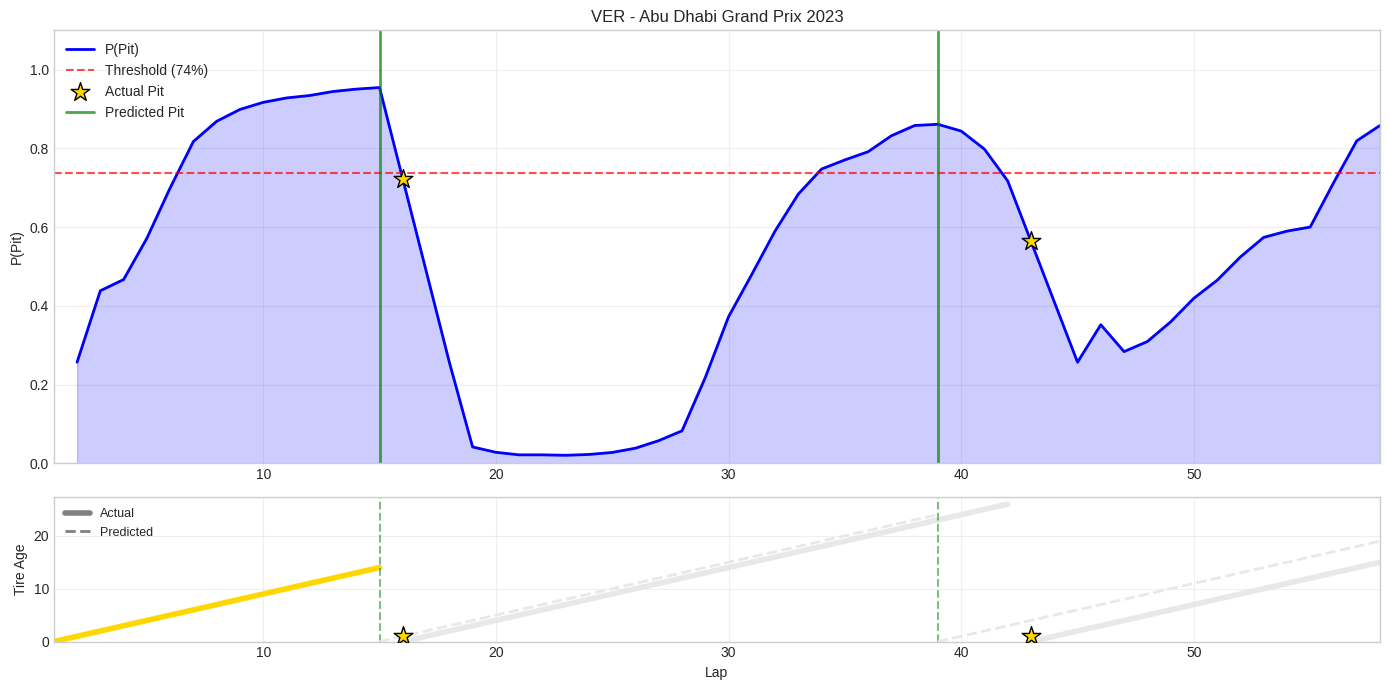

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), height_ratios=[3, 1])
data = sim_df[sim_df['DataAvailable']]
total_laps = int(sim_df['TotalLaps'].iloc[0])
STAR_SIZE = 200
pit_laps_sorted = sorted(list(pit_laps))

# ====== TOP PLOT: Pit Probability ======
ax1 = axes[0]

# P(Pit) curve
ax1.plot(data['Lap'], data['PitProb'], 'b-', linewidth=2, label='P(Pit)')
ax1.fill_between(data['Lap'], 0, data['PitProb'], alpha=0.2, color='blue')

# Threshold line
ax1.axhline(y=PIT_THRESHOLD, color='red', linestyle='--',
            linewidth=1.5, alpha=0.7, label=f'Threshold ({PIT_THRESHOLD:.0%})')

# Actual pit stops (stars)
for i, pit in enumerate(pit_laps_sorted):
    # Interpolate probability at pit lap
    if pit < data['Lap'].min() or pit > data['Lap'].max():
        prob = PIT_THRESHOLD
    else:
        prob = np.interp(pit, data['Lap'].values, data['PitProb'].values)

    ax1.scatter([pit], [prob], color='gold', s=STAR_SIZE, marker='*',
                zorder=6, edgecolors='black', linewidths=1,
                label='Actual Pit' if i == 0 else '')

# Predicted pit stops (green lines)
for i, info in enumerate(recommended_pits.values()):
    ax1.axvline(x=info['lap'], color='green', linewidth=2, alpha=0.7,
                label='Predicted Pit' if i == 0 else '')

ax1.set_xlim(1, total_laps)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('P(Pit)')
ax1.set_title(f'{DRIVER} - {race_name} {YEAR}')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# ====== BOTTOM PLOT: Tire Strategy ======
ax2 = axes[1]
sim_df_sorted = sim_df.sort_values(['Stint', 'Lap'])

# Actual strategy (solid lines)
for stint_int, sdata in sim_df_sorted.groupby('Stint'):
    compound = sdata['Compound'].iloc[0]
    color = COMPOUND_COLORS.get(compound, 'gray')
    laps = sdata['Lap'].tolist()
    tyre_age = [lap - laps[0] for lap in laps]
    ax2.plot(laps, tyre_age, color=color, linewidth=4, zorder=2)

# Build predicted compounds dict
pred_compounds = {}
for pit_lap in sorted(pit_laps):
    pit_row = sim_df[sim_df['Lap'] == pit_lap]
    if len(pit_row) > 0 and pd.notna(pit_row['CompPred'].iloc[0]):
        next_stint = int(pit_row['Stint'].iloc[0])
        pred_compounds[next_stint] = pit_row['CompPred'].iloc[0]

# Predicted strategy (dashed lines)
pred_pits_sorted = []
for i, info in enumerate(recommended_pits.values()):
    stint_num = i + 2  # Stint 2, 3, ...
    if stint_num in pred_compounds:
        pred_pits_sorted.append((info['lap'], pred_compounds[stint_num]))

pred_pits_sorted = sorted(pred_pits_sorted, key=lambda x: x[0])

for i, (pred_lap, pred_compound) in enumerate(pred_pits_sorted):
    next_lap = pred_pits_sorted[i + 1][0] if i + 1 < len(pred_pits_sorted) else total_laps
    pred_laps = list(range(pred_lap, next_lap + 1))
    pred_tyre_age = list(range(len(pred_laps)))
    color = COMPOUND_COLORS.get(pred_compound, 'gray')
    ax2.plot(pred_laps, pred_tyre_age, color=color, linewidth=2,
             linestyle='--', zorder=3)

# Pit markers
STAR_Y = 1
for pit in pit_laps_sorted:
    ax2.scatter(pit, STAR_Y, color='gold', s=STAR_SIZE, marker='*',
                zorder=6, edgecolors='black', linewidths=1)

for info in recommended_pits.values():
    ax2.axvline(x=info['lap'], color='green', linestyle='--',
                linewidth=1.5, alpha=0.5)

# Legend
ax2.plot([], [], color='gray', linewidth=4, label='Actual')
ax2.plot([], [], color='gray', linewidth=2, linestyle='--', label='Predicted')

ax2.set_xlim(1, total_laps)
ax2.set_ylim(0, None)
ax2.set_xlabel('Lap')
ax2.set_ylabel('Tire Age')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 6. Save Results

Export simulation to CSV and chart to PNG.

In [15]:
dirname = f"{YEAR}_R{ROUND}_{DRIVER}"
os.makedirs(dirname, exist_ok=True)

In [16]:
# Full simulation CSV
sim_df.to_csv(os.path.join(dirname, 'simulation.csv'), index=False)

# Summary CSV
pit_summary = []
for stint in range(1, num_stints + 1):
    row = {
        'Stint': stint,
        'Compound': sim_df[sim_df['Stint'] == stint]['Compound'].iloc[0]
    }

    if stint == num_stints:
        row.update({
            'RecLap': None, 'RecProb': None, 'ActualLap': None,
            'Diff': None, 'NextCompound': None, 'PredCompound': None,
            'CompMatch': None
        })
    elif stint in recommended_pits:
        rec = recommended_pits[stint]
        row['RecLap'] = rec['lap']
        row['RecProb'] = round(rec['prob'], 3)

        pit_rows = sim_df[
            (sim_df['Stint'] == stint + 1) &
            (sim_df['PitThisLap'] == 1)
        ]

        if len(pit_rows) > 0:
            actual = int(pit_rows['Lap'].iloc[0])
            row['ActualLap'] = actual
            row['Diff'] = actual - rec['lap']
            row['NextCompound'] = pit_rows['CompActual'].iloc[0]
            row['PredCompound'] = pit_rows['CompPred'].iloc[0]
            row['CompMatch'] = row['NextCompound'] == row['PredCompound']

    pit_summary.append(row)

pd.DataFrame(pit_summary).to_csv(os.path.join(dirname, 'summary.csv'), index=False)

# Save chart
fig.savefig(os.path.join(dirname, 'chart.png'), dpi=150, bbox_inches='tight')

print('\nFiles saved:')
print(f'  ✓ {dirname}/simulation.csv')
print(f'  ✓ {dirname}/summary.csv')
print(f'  ✓ {dirname}/chart.png')


Files saved:
  ✓ 2023_R22_VER/simulation.csv
  ✓ 2023_R22_VER/summary.csv
  ✓ 2023_R22_VER/chart.png
